# Plot DEGs & scores

<br>

* Re-process all samples together for plotting (except ribo batch)

* Score by upregulated genes

<br>


Select kernel: Single Cell R (4.3)

------


In [1]:
##### ----- Load libraries
requiredPackages <- c("edgeR","GSEABase", "data.table", "limma", "cowplot", "ggplot2", "dplyr","Matrix", "singscore", "biomaRt", "cowplot") #"Manu",ggscireadxl

for (pkg in requiredPackages){
  suppressWarnings(suppressMessages(library(pkg, character.only = T)))
}


fig <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
 }

##### ----- Get directories
raw_data_path = "/lustre/scratch125/cellgen/behjati/jp40/pipelines/6_RNA/data/counts/"
data_save_dir = "/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/output/rna/"
sample_sheet_dir = "/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/metadata/"
                   
sample_sheet_df = read.table(paste0(sample_sheet_dir,"driver_and_manifest_table_2026_07_03_pm.csv"), sep=",", skip=1, header=TRUE)

<br>

<br>

## 1) Re-process data for scoring

-----

In [2]:
## -- Load data
counts_df <- read.table(paste0(data_save_dir, "combined_raw_counts.csv"), sep=",", header=TRUE,row.names=NULL)
counts_df <- counts_df[!grepl("^RP11-", counts_df$gene_name) &!grepl("^RPL", counts_df$gene_name),]

## -- Get library info
samples_r = read.table("ribozero.txt", sep="\t", header=FALSE)
samples_o = read.table("oligo.txt", sep="\t", header=FALSE)
missing_IDs <- setdiff(colnames(counts_df),c(samples_r$V1,samples_o$V1))
df_x = data.table(samples=c(samples_r$V1,samples_o$V1, missing_IDs),
          library=c(rep("ribo", length(samples_r$V1)), rep("oligo", length(samples_o$V1)), rep("NA", length(missing_IDs))))

## -- Get gene info
genes_df <- counts_df[,colnames(counts_df) %in% c("ensid", "gene_name"),]
rownames(genes_df) <- genes_df$ensid

## -- Prep data
rownames(counts_df) <- counts_df$ensid
counts_df <- counts_df[, !(colnames(counts_df) %in% c("ensid", "gene_name", "X"))]

## -- Get sample data
samples_df <- data.frame(sampleID = colnames(counts_df),
                                   library=as.vector(setNames(df_x$library, df_x$samples)[colnames(counts_df)]))

## -- Append more
cols_to_add <- c("Tumour.type", "Risk.category", "Event", "Outcome", "Outcome_qualifier", 
                 "sample_category", "Sample.type", "Age_at_diagnosis_months", "Sex", 
                 "Mets_at_ddx", "Predisposition", "Relapse_or_progression",
                "Event_free_survival", "Overall_survival", "Histology_of_this_specimen")

append_col <- function(col_x){return(as.vector(setNames(sample_sheet_df[[col_x]],
                                                  sample_sheet_df$RNA_ID)[colnames(counts_df)]))}

for (i in cols_to_add){
    samples_df[[i]] <- append_col(i)
}

## -- Add new group
x = samples_df[samples_df$Event %in% c("Relapse_alive", "Relapse_death"),]$sampleID
y = samples_df[samples_df$Outcome %in% c("Dead"),]$sampleID
z <- unique(c(x,y))
samples_df$all_outcome <- ifelse(samples_df$sampleID %in% z, "Bad", "Good")



In [3]:
## -- add purity
purity_df <- read.csv("/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/metadata/purity_predisp.csv",
               header = TRUE, check.names = FALSE,stringsAsFactors = FALSE)

id_dict = setNames(sample_sheet_df$RNA_ID,sample_sheet_df$Sample)
purity_a_dict = setNames(purity_df$`Purity Estimate - ASCAT`, as.vector(id_dict[purity_df$DNA_ID]) )
purity_b_dict = setNames(purity_df$`Purity Estimate - Battenberg`, as.vector(id_dict[purity_df$DNA_ID]))

samples_df$purity <- as.vector(purity_a_dict[samples_df$sampleID])
samples_df$purity <- replace(samples_df$purity, samples_df$purity=="not_applicable", NA)
samples_df$purity  <- as.numeric(samples_df$purity)

Warning message:
“NAs introduced by coercion”


<br>

#### Subset data

In [4]:
## -- Subset to Wilms
samples_df <- samples_df[samples_df$Tumour.type == "Wilms",]

## -- Remove ribo
samples_df <- samples_df[!(samples_df$library %in% c("ribo")),]

## -- Otherwise clean
samples_df <- samples_df[!(samples_df$Outcome== "unavailable"),]

## -- Remove not really wilms
samples_df <- samples_df[!(samples_df$Histology_of_this_specimen %in% c("Nephroblastomatosis")),]

## -- Remove low purity
samples_df <- samples_df[samples_df$purity > 0.6,]
samples_df <- samples_df[!(is.na(samples_df$purity)),]

## -- Subset
counts_df <- counts_df[,colnames(counts_df) %in% samples_df$sampleID]


In [5]:
table(samples_df$Histology_of_this_specimen)


                  Blastemal         Completely necrotic 
                         43                           6 
          Diffuse anaplasia                  Epithelial 
                         30                          42 
            Focal anaplasia                       Mixed 
                         11                         125 
Non anaplastic and variants                  Regressive 
                         41                          82 
                    Stromal 
                         72 

In [6]:
## -- rows are genes, columns are samples
wilms_dge <- edgeR::DGEList(counts_df,
               group = samples_df$all_outcome,#$Outcome,
               samples = samples_df,
               genes=genes_df)
              

<br>

<br>

## Process counts

-----

In [7]:
annot <- wilms_dge$genes[match(rownames(wilms_dge), wilms_dge$genes$ensid), ]
drop <- grepl("^MT-|^RPL|^RPS|^MRPL|^MRPS", annot$gene_name) |
        grepl("^RN7SK|^RN7SL|^RNU[0-9]|^RNVU|^SNOR|^SCARNA|^MIR[0-9]",
              annot$gene_name) |
        grepl("^RNA5S|^RNA18S|^RNA28S|^RMRP|^RPPH1", annot$gene_name)
cat("dropping", sum(drop), "structural / small RNA genes\n")
wilms_dge <- wilms_dge[!drop, ]

dropping 5687 structural / small RNA genes


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


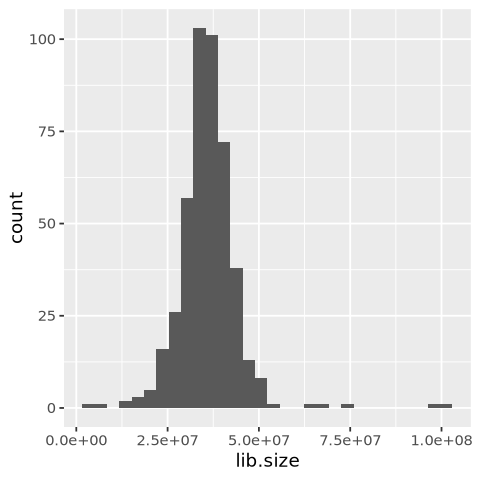

In [8]:
fig(4,4)
ggplot(data=wilms_dge$samples,aes(x=lib.size))+geom_histogram()

In [9]:
## -- minimum library size -- between 1 million and 100 million
wilms_dge <- wilms_dge[,(wilms_dge$samples$lib.size > 1e7) & (wilms_dge$samples$lib.size < 6e7) ] 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


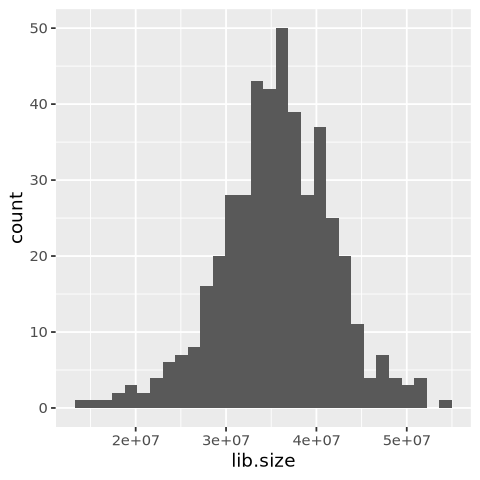

In [10]:
fig(4,4)
ggplot(data=wilms_dge$samples,aes(x=lib.size))+geom_histogram()

keep
FALSE  TRUE 
14177 15148 


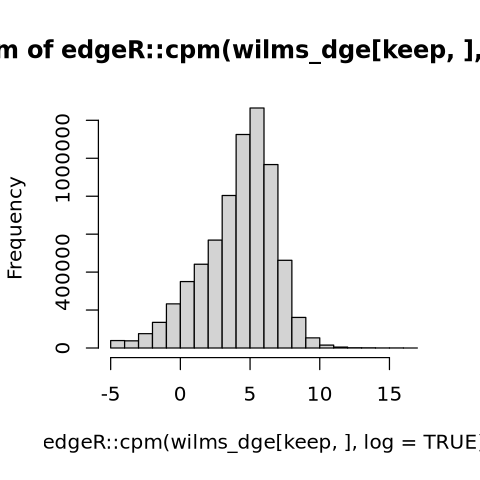

In [11]:
fig(4, 4)
keep = rowMeans(edgeR::cpm(y=wilms_dge, log = TRUE) >= 0.5) >= 0.2
#keep <- filterByExpr(wilms_dge)
hist(edgeR::cpm(wilms_dge[keep, ], log = TRUE))
print(table(keep))

In [12]:
wilms_dge <- wilms_dge[keep, ]

In [13]:
## -- Design matrix
group_factor <- as.factor(wilms_dge$samples$group)
other_factor <- as.factor(wilms_dge$samples$Histology_of_this_specimen)  # + Predisposition // Histology_of_this_specimen // Outcome
design_x <- model.matrix( ~0 +  group_factor + other_factor)
wilms_dge$design <- design_x

In [14]:
## -- Process counts
wilms_dge <- edgeR::calcNormFactors(wilms_dge, method="RLE")
wilms_dge$logCPM <- edgeR::cpm(wilms_dge, log=TRUE, prior.count = 1,
                             normalized.lib.sizes=TRUE, lib.size=wilms_dge$samples$lib.size)

## -- Estimate Dispersions
wilms_dge <- estimateDisp(wilms_dge, wilms_dge$design, robust=TRUE)

<br>

#### Add RPKM

In [15]:
gene_length_df = read.table("/lustre/scratch124/casm/pipelines/canpipe/live/ref/Homo_sapiens/GRCh37d5/cgpRna/e75/ensembl.gene_length.tsv", sep="\t", header=TRUE)
gene_len_dict = setNames(gene_length_df$median,gene_length_df$ensid)
wilms_dge$genes$gene_length <- as.vector(gene_len_dict[rownames(wilms_dge)])

In [16]:
wilms_dge$logRPKM <- rpkm(wilms_dge, log=TRUE, prior.count = 1, gene.length = wilms_dge$genes$gene_length)

In [17]:
## -- Save
saveRDS(wilms_dge, file =paste0(data_save_dir,"objects/",  "wilms_plotting_dge.rds"))

<br>

<br>

## 2) Score & plot

-----

#### Get module

In [18]:
other_dir="/nfs/users/nfs_h/hw12/WILMS/gene_sigs/"
bad_genes <- read.table(paste0(other_dir,"Intermediate_DE_UP_genes.txt"),sep="\t")$UP_genes
good_genes <- read.table(paste0(other_dir,"Intermediate_DE_DN_genes.txt"),sep="\t" )$DN_genes

In [32]:
tt_outcome <- read.table(paste0(data_save_dir,"GoodvsBad_Intermediate_DE_output.txt"),sep="\t" ) 
bad_gene_strict <- tt_outcome[tt_outcome$logFC > 1& (tt_outcome$FDR < 0.05),]$gene_name

In [33]:
length(intersect(bad_genes,bad_gene_strict))


[1] 18

In [34]:
length(bad_gene_strict)

[1] 83

In [35]:
length(bad_genes)

[1] 59

#### Score

In [36]:
## -- use gene names
wilms_dge_tmp <- wilms_dge[!(duplicated(wilms_dge$genes$gene_name)),]
wilms_dge_tmp$logCPM <- wilms_dge$logCPM[!(duplicated(wilms_dge$genes$gene_name)),]
wilms_dge_tmp$logRPKM <- wilms_dge$logRPKM[!(duplicated(wilms_dge$genes$gene_name)),]

rownames(wilms_dge_tmp) <- wilms_dge_tmp$genes$gene_name
rownames(wilms_dge_tmp$logCPM) <- wilms_dge_tmp$genes$gene_name
rownames(wilms_dge_tmp$logRPKM) <- wilms_dge_tmp$genes$gene_name

In [37]:
rankData <- rankGenes(wilms_dge_tmp$logRPKM)

## -- both
scoredf <- simpleScore(rankData, upSet = unique(bad_genes), downSet=unique(good_genes), centerScore=FALSE)
wilms_dge$samples$bad_genes_score <- as.vector(scoredf$TotalScore)

## -- only up
scoredf <- simpleScore(rankData, upSet = unique(bad_genes),  centerScore=FALSE)
wilms_dge$samples$bad_genes_score_up <- as.vector(scoredf$TotalScore)

## -- only up -- strict
scoredf <- simpleScore(rankData, upSet = unique(bad_gene_strict),  centerScore=FALSE)
wilms_dge$samples$bad_genes_score_up_strict <- as.vector(scoredf$TotalScore)

Warning message in checkGenes(upSet, rownames(rankData)):
“1 genes missing: GRIA1”


<br>

#### Plot


In [127]:
library(ggbeeswarm)

wilms_dge$samples$Risk.category <- factor(wilms_dge$samples$Risk.category, levels=c("Low risk","Intermediate risk","High risk"))
wilms_dge$samples$all_outcome <- factor(wilms_dge$samples$all_outcome, levels=c("Good","Bad"))

plot_scores <- function(score_str, remove_focal_ana=FALSE){

    df_x <- wilms_dge$samples
    df_x$score <- df_x[[score_str]]
    
    if (remove_focal_ana){
        df_x <- df_x[!(df_x$Histology_of_this_specimen %in% c("Focal anaplasia")),]
    }
    
    
    gg1 <-ggplot(data=df_x, aes(x=reorder(Risk.category,score),y=score, fill=all_outcome))+
                            geom_boxplot(position = position_dodge(width = 0.75))+
                            geom_beeswarm(aes(group = interaction(Risk.category, all_outcome)),dodge.width = 0.75, cex = 0.6, alpha=1)+
                            theme_bw()+  labs(x="", y=score_str, fill="Overall outcome \n(death & relapse)")+
                            scale_x_discrete(expand=c(0,0)) + scale_y_continuous(expand=c(0,0)) + 
                    scale_fill_manual(values=setNames(c("#7B8BA5","#B66A40"),  c("Good","Bad")))+
                    theme(axis.text=element_text(size=18),
                          axis.title.x=element_blank(), axis.title.y=element_text(size=20, margin=margin(0,10,0,0)),
                            legend.title = element_text(size = 20), legend.text = element_text(size = 16),
                                legend.key.size = unit(1.2, "cm")) 


    gg2 <- ggplot(data=df_x, aes(x=reorder(Risk.category,score),y=score, fill=Outcome))+
                        geom_boxplot(position = position_dodge(width = 0.75))+
                            geom_beeswarm(aes(group = interaction(Risk.category, Outcome)),dodge.width = 0.75, cex = 0.6, alpha=1)+
                        theme_bw()+ labs(x="", y=score_str, fill="Outcome (death)")+
                            scale_x_discrete(expand=c(0,0)) + scale_y_continuous(expand=c(0,0)) + 
                    scale_fill_manual(values=setNames(c("#287DAB","#B8321A"),  c("Alive","Dead")))+
                    theme(axis.text=element_text(size=18),
                          axis.title.x=element_blank(), axis.title.y=element_text(size=20, margin=margin(0,10,0,0)),
                            legend.title = element_text(size = 20), legend.text = element_text(size = 16),
                                legend.key.size = unit(1.2, "cm")) 
    
    return(cowplot::plot_grid(gg1,gg2))
}

<br>

#### Plot bi-directional sig

Removing Focal anaplasia makes it look slightly better

In [128]:
wilcox.test(wilms_dge$samples[(wilms_dge$samples$all_outcome =="Bad") & (wilms_dge$samples$Risk.category =="Intermediate risk"),]$bad_genes_score,
                      wilms_dge$samples[(wilms_dge$samples$all_outcome =="Good") & (wilms_dge$samples$Risk.category =="Intermediate risk"),]$bad_genes_score)$p.value

[1] 3.181564e-05

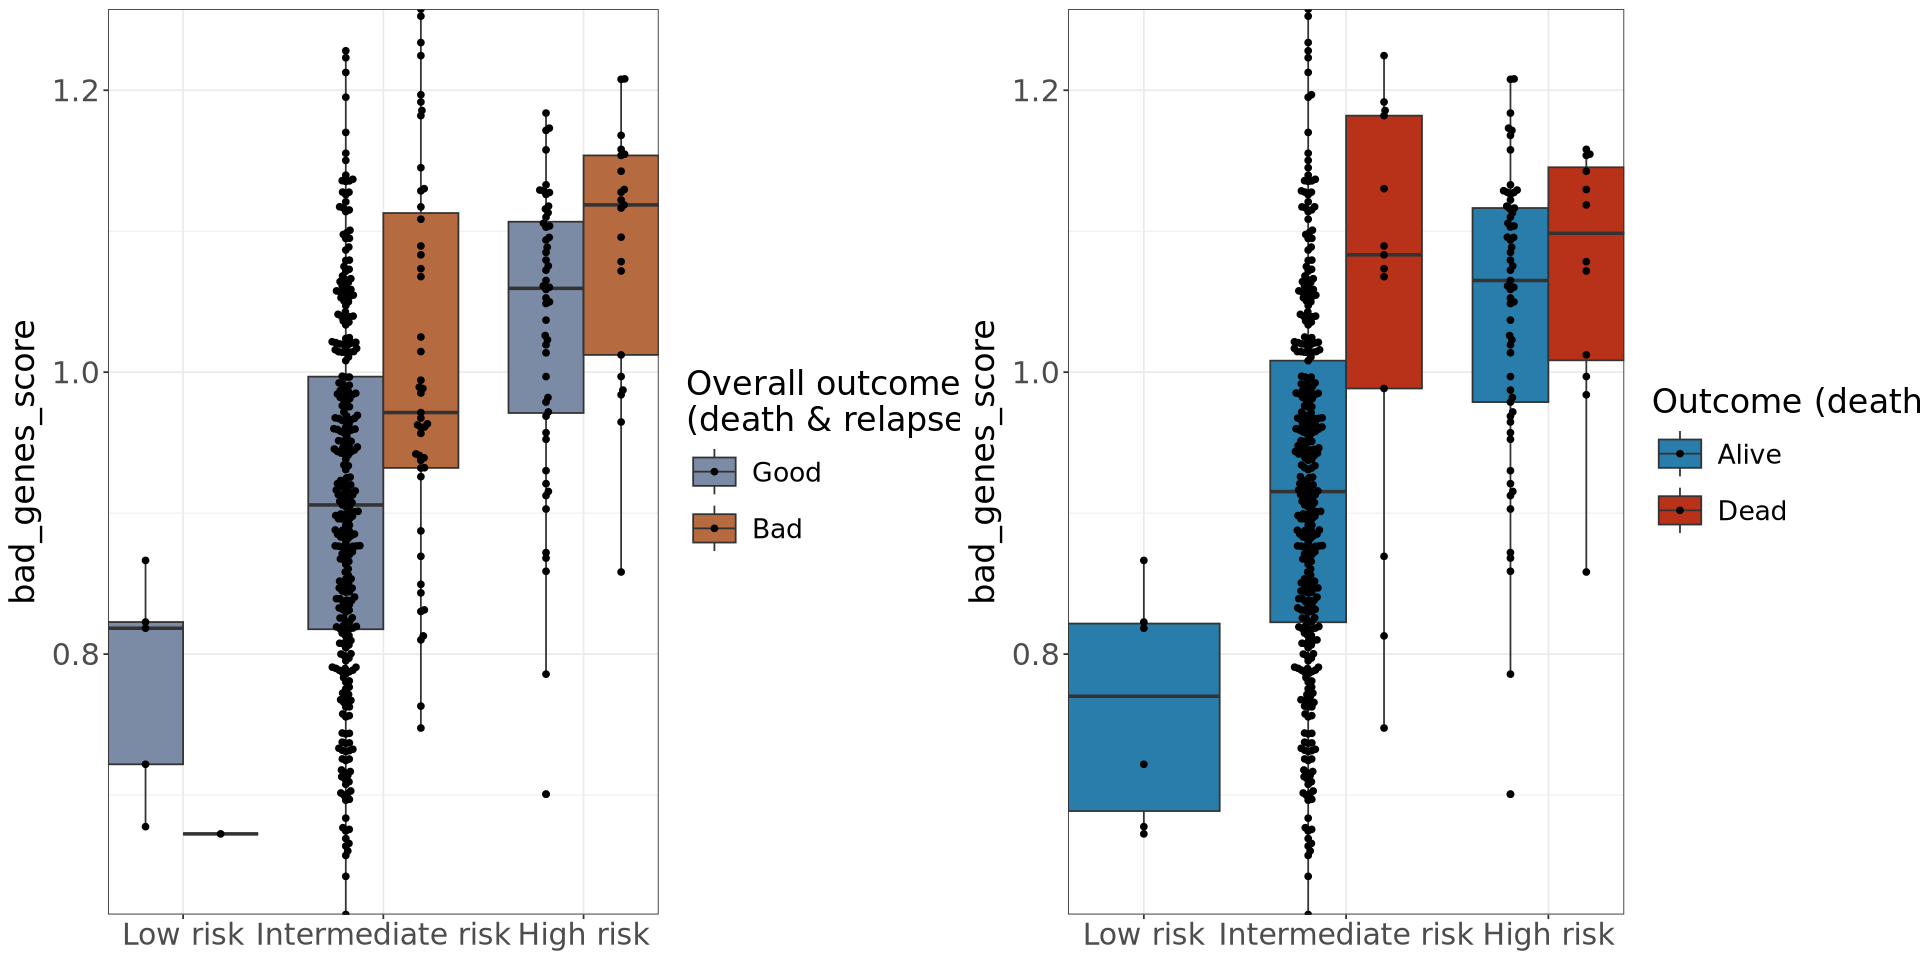

In [129]:
fig(16,8)
plot_scores("bad_genes_score", remove_focal_ana=FALSE)

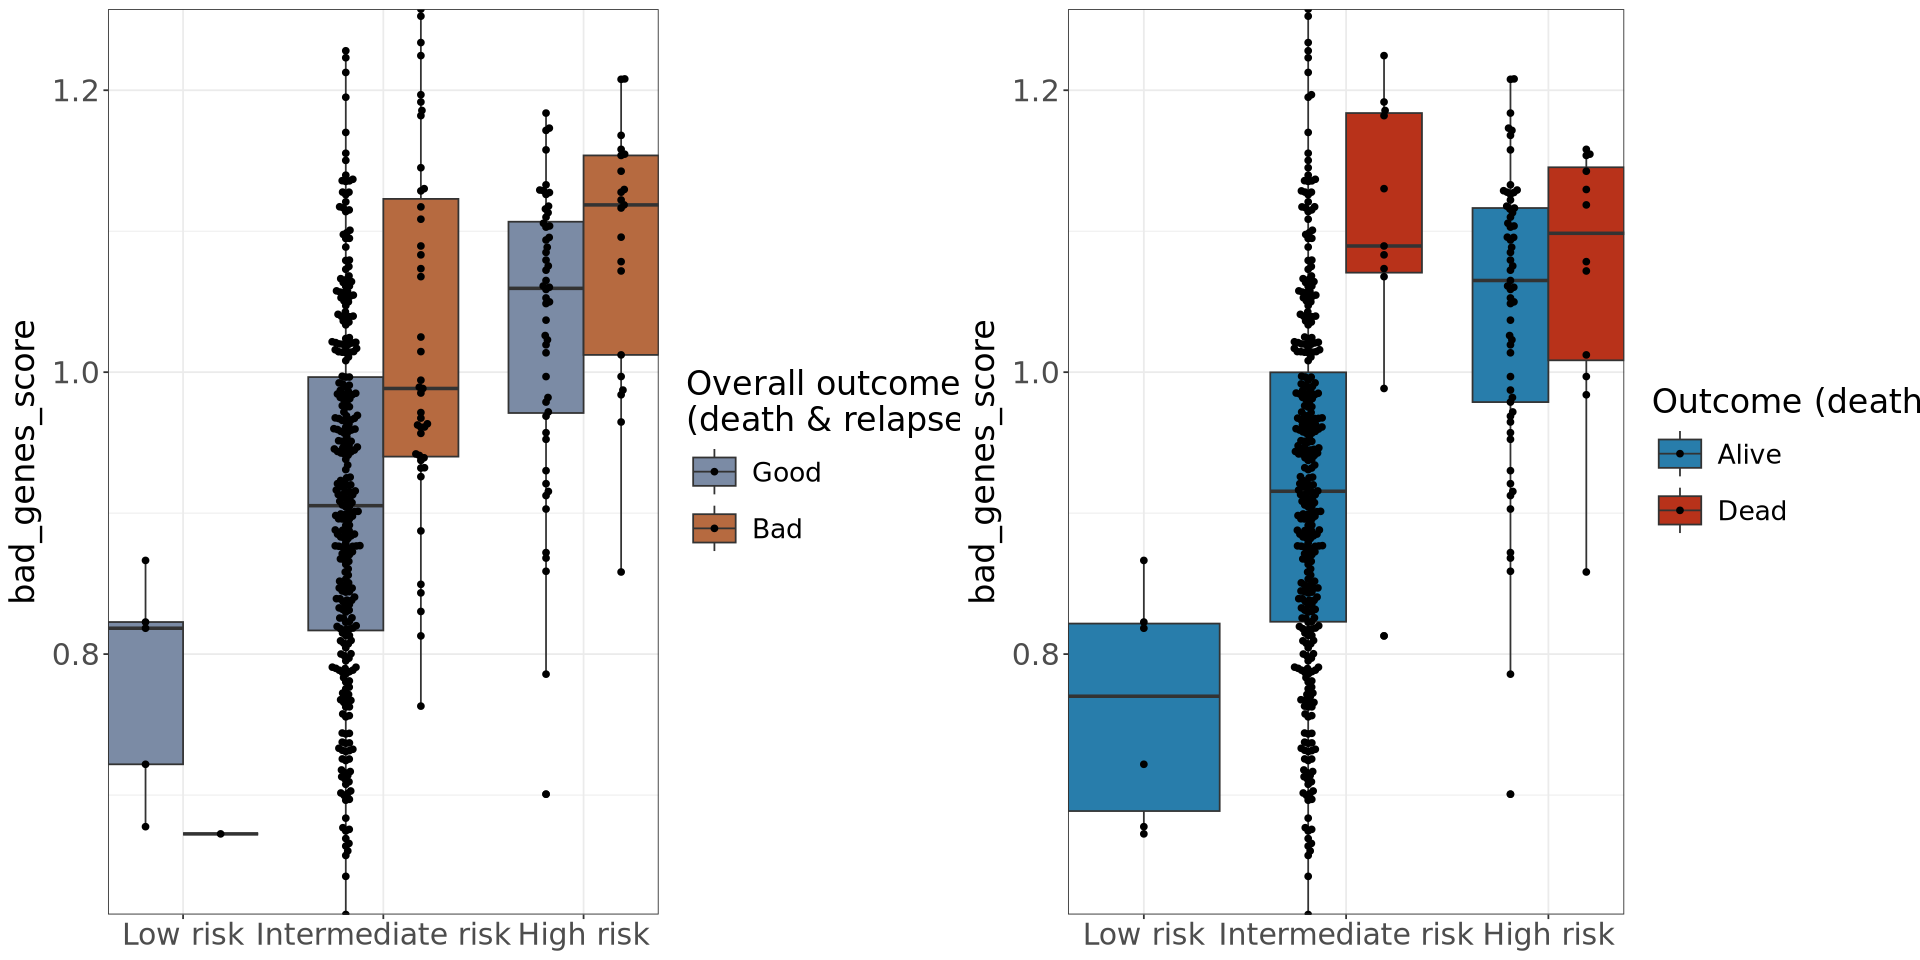

In [130]:
fig(16,8)
plot_scores("bad_genes_score", remove_focal_ana=TRUE)

<br>

#### Plot one-directional sig



In [131]:
wilcox.test(wilms_dge$samples[(wilms_dge$samples$all_outcome =="Bad") & (wilms_dge$samples$Risk.category =="Intermediate risk"),]$bad_genes_score_up,
                      wilms_dge$samples[(wilms_dge$samples$all_outcome =="Good") & (wilms_dge$samples$Risk.category =="Intermediate risk"),]$bad_genes_score_up)$p.value

[1] 1.138914e-05

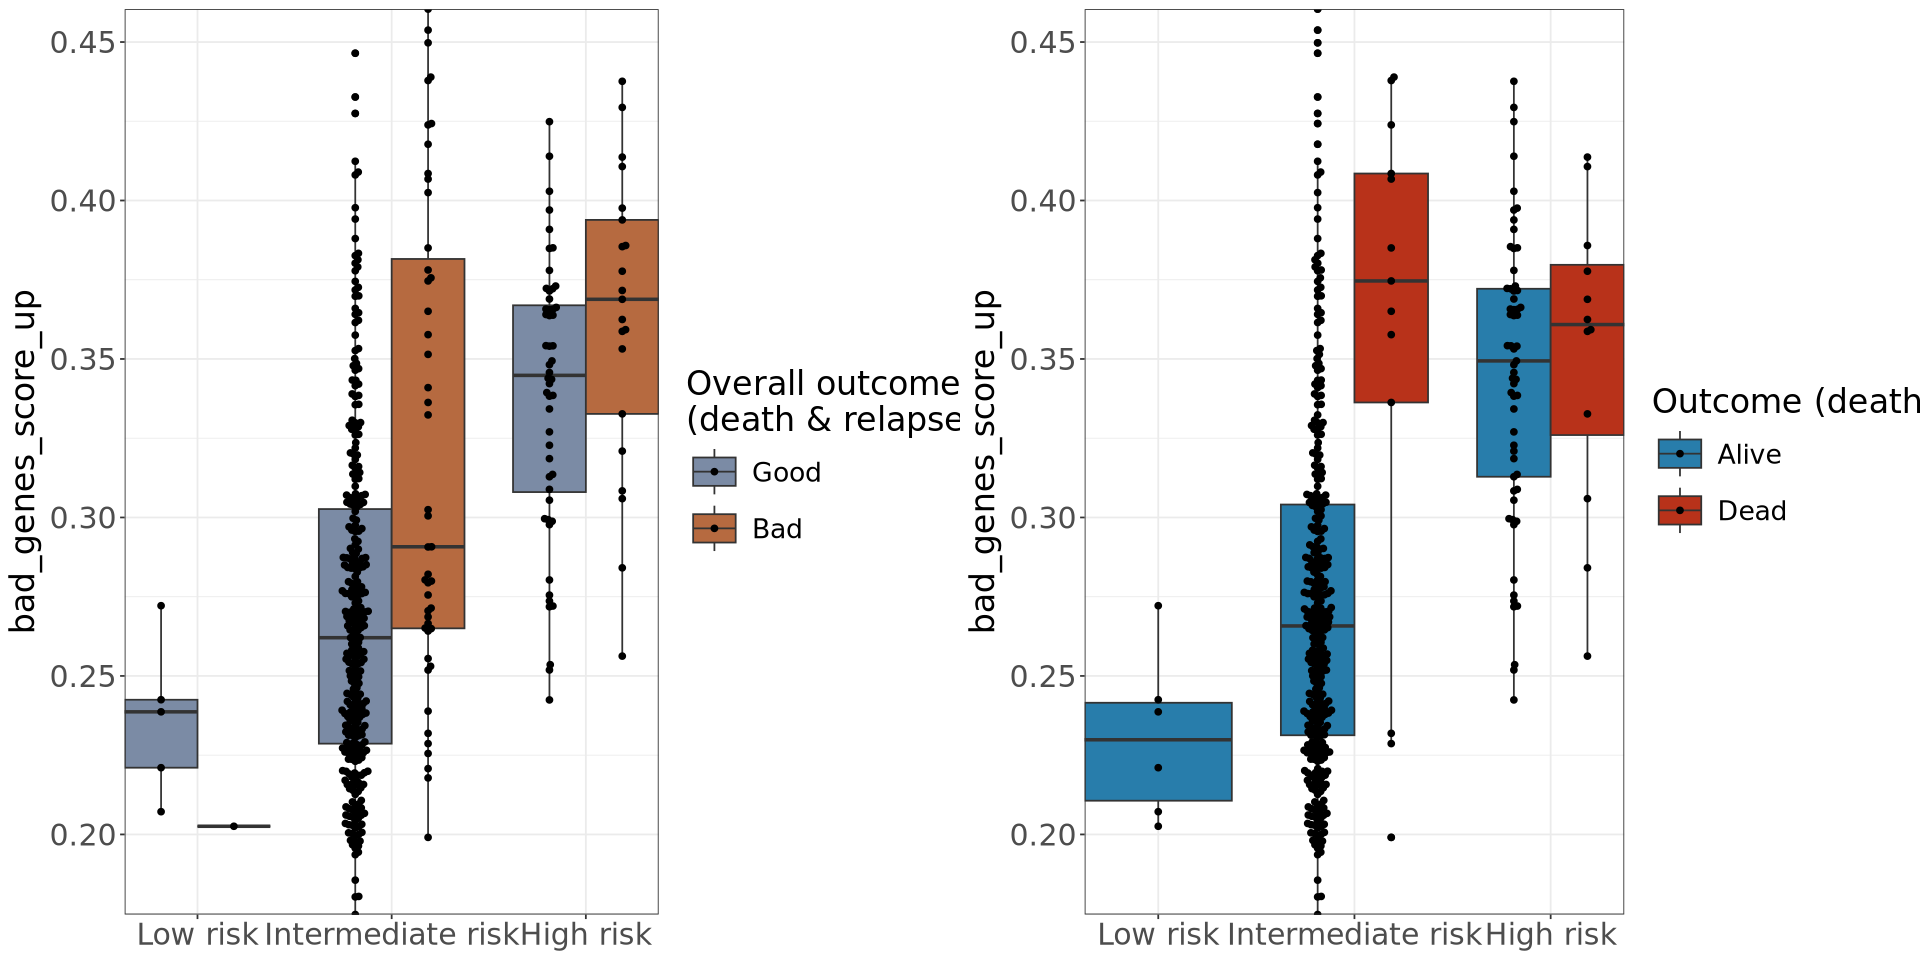

In [132]:
fig(16,8)
plot_scores("bad_genes_score_up", remove_focal_ana=FALSE)

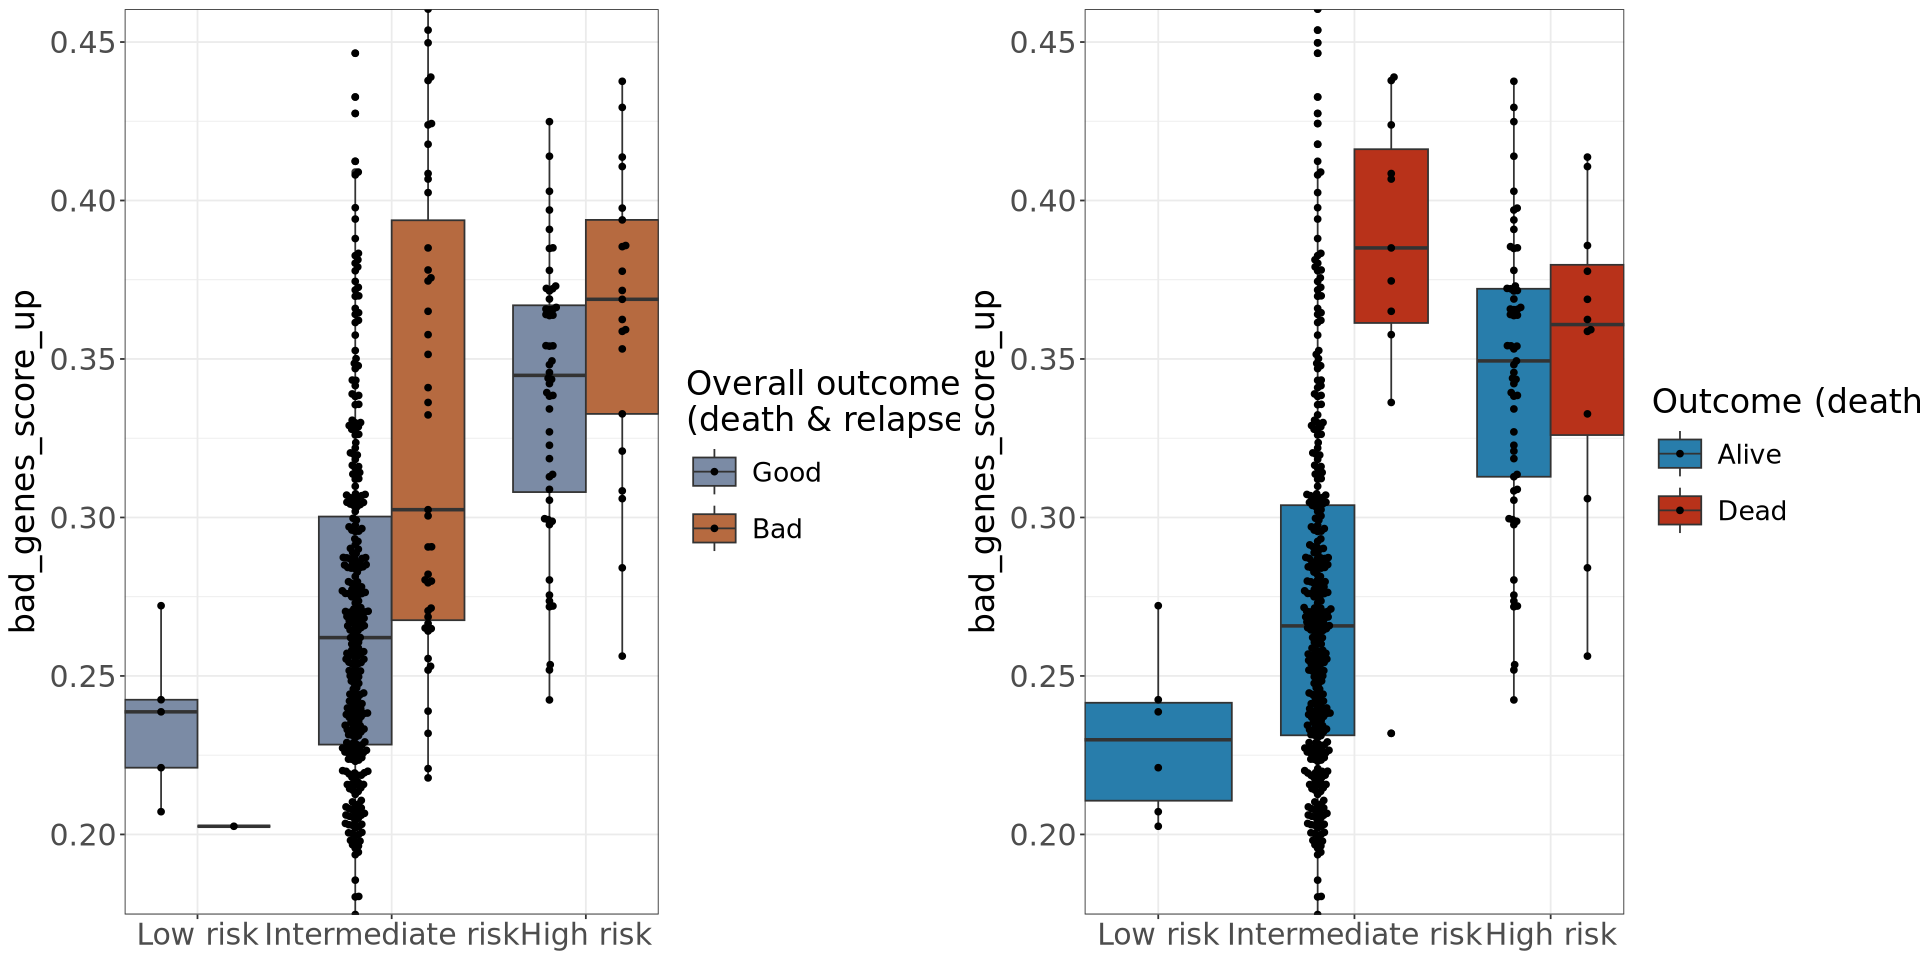

In [133]:
fig(16,8)
plot_scores("bad_genes_score_up", remove_focal_ana=TRUE)

<br>

#### Plot strict sig


In [135]:
wilcox.test(wilms_dge$samples[(wilms_dge$samples$all_outcome =="Bad") & (wilms_dge$samples$Risk.category =="Intermediate risk"),]$bad_genes_score_up_strict,
                      wilms_dge$samples[(wilms_dge$samples$all_outcome =="Good") & (wilms_dge$samples$Risk.category =="Intermediate risk"),]$bad_genes_score_up_strict)$p.value

[1] 4.977265e-05

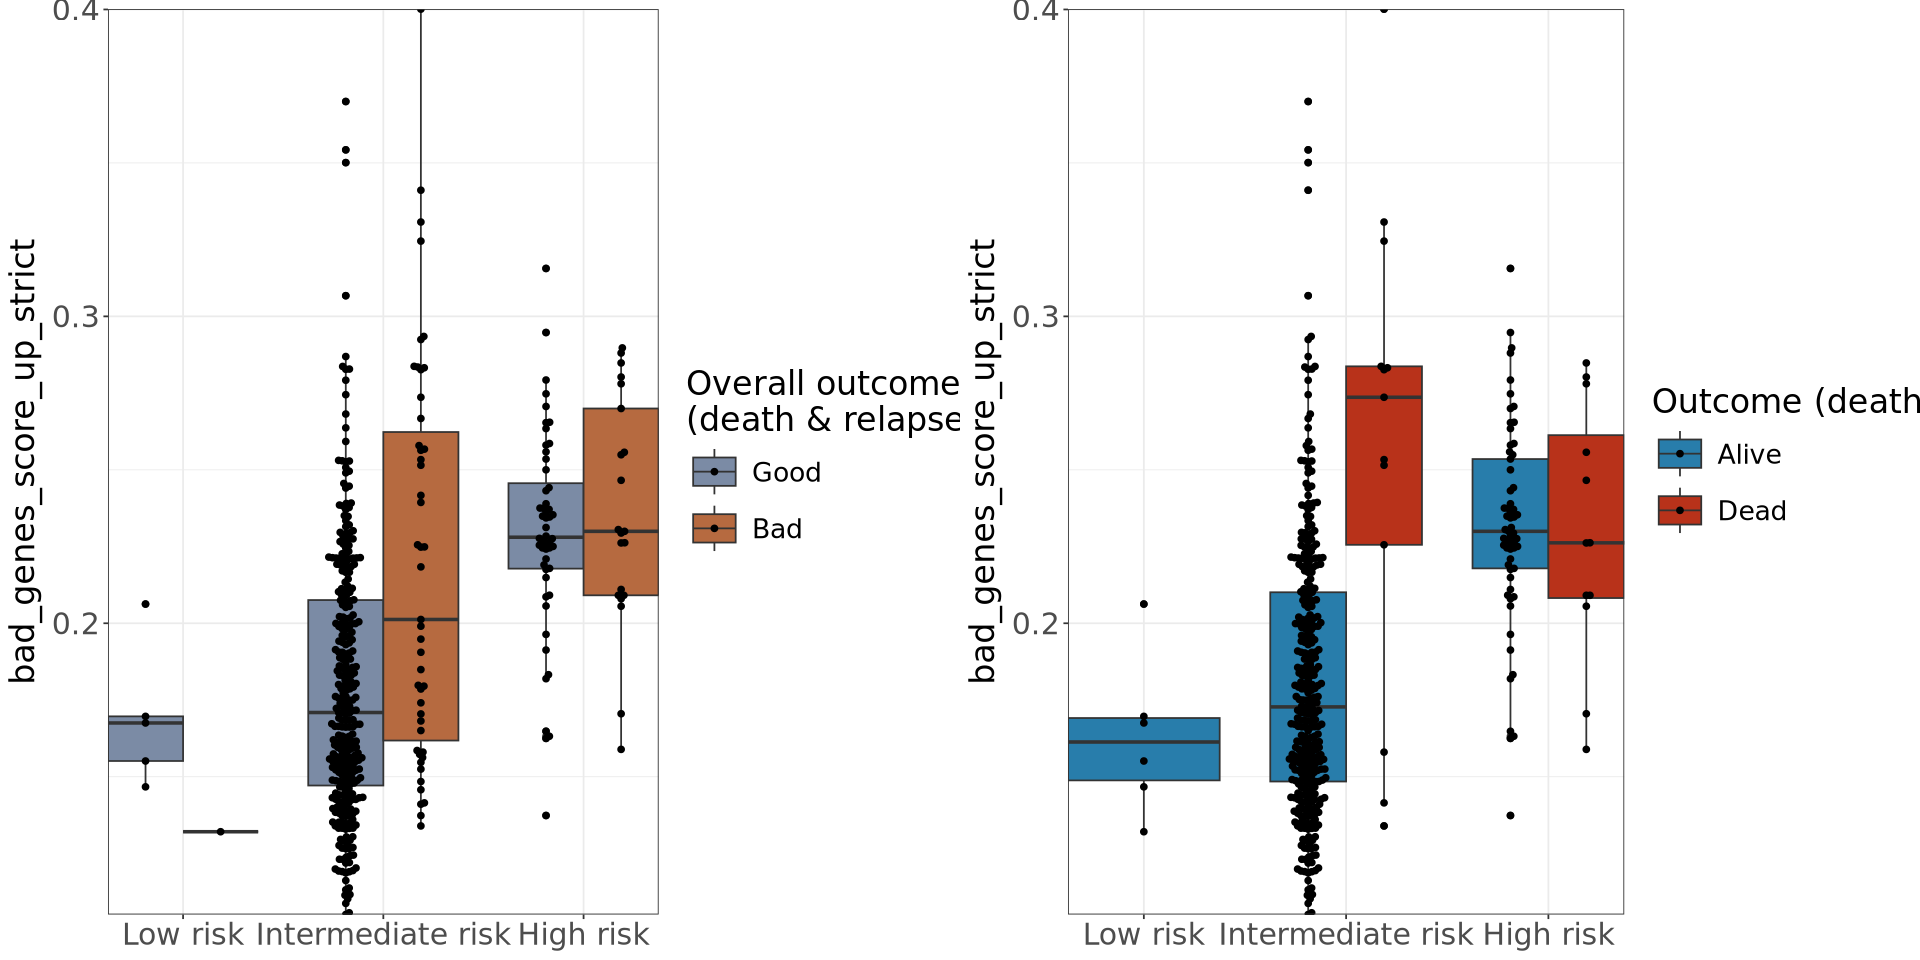

In [136]:
fig(16,8)
plot_scores("bad_genes_score_up_strict", remove_focal_ana=FALSE)

<br>

<br>

#### By histology

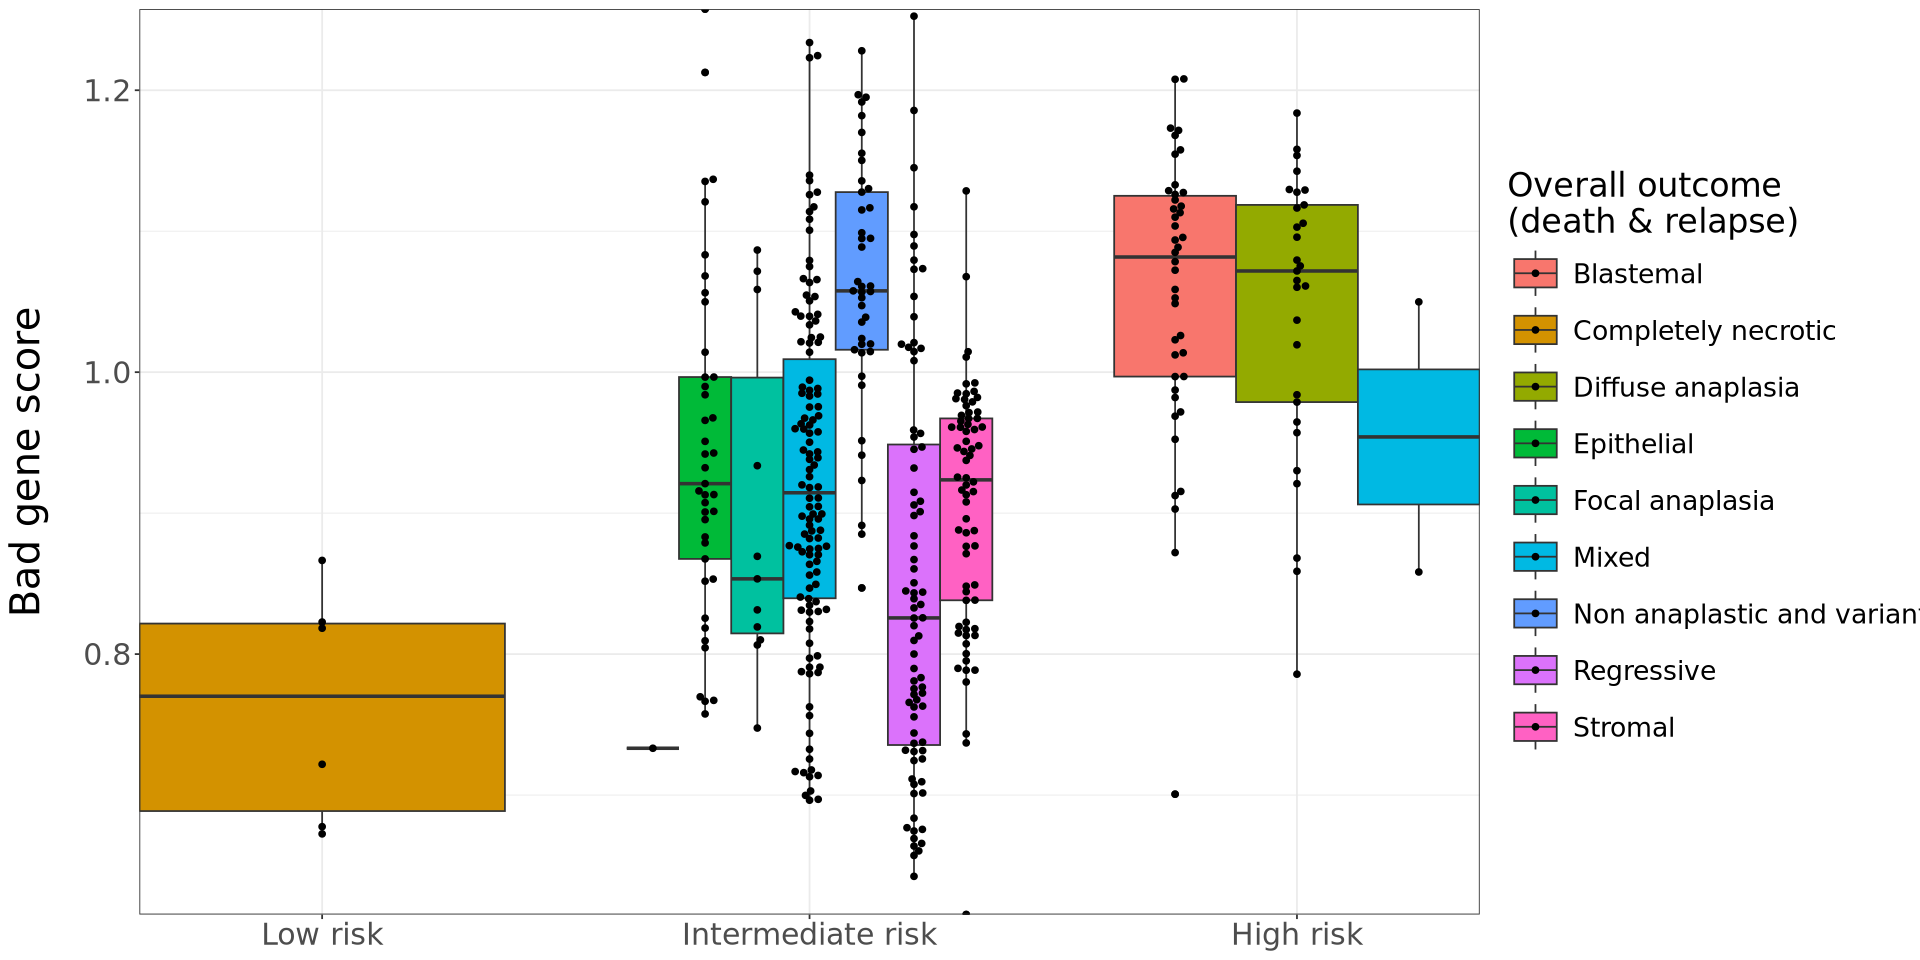

In [137]:
wilms_dge$samples$scores_x <- wilms_dge$samples$bad_genes_score
    
ggplot(data=wilms_dge$samples, aes(x=reorder(Risk.category,scores_x),y=scores_x, fill=Histology_of_this_specimen))+
                            geom_boxplot(position = position_dodge(width = 0.75))+
                        geom_beeswarm(aes(group = interaction(Risk.category, Histology_of_this_specimen)),dodge.width = 0.75, cex = 0.6, alpha=1)+theme_bw()+ #labs(y="")+
                            scale_x_discrete(expand=c(0,0)) + scale_y_continuous(expand=c(0,0)) + 
                            labs(x="", y="Bad gene score", fill="Overall outcome \n(death & relapse)")+
                    theme(axis.text=element_text(size=18),
                          axis.title.x=element_blank(), axis.title.y=element_text(size=24, margin=margin(0,25,0,0)),
                            legend.title = element_text(size = 20), legend.text = element_text(size = 16),
                                legend.key.size = unit(1.2, "cm")) 